**Goal:**
Applying LSTM Seq2seq classification for classifying severity of football injuries as Minor(<=7 days), Moderate(8 to 28 days) and Severe (more than 28 days).

## 1. Data Loading and Initial Inspection

Based on your project outline, the first step is to load and understand the datasets. I'll start by loading the `dataset.csv` file that is available in the kernel environment.

In [1]:
import pandas as pd

# Load the dataset.csv file
df = pd.read_csv('/content/dataset.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display general information about the DataFrame, including data types and non-null values
print('\nDataFrame Info:')
df.info()

First 5 rows of the dataset:


,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96968 entries, 0 to 96967
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    96968 non-null  int64  
 1   injury_code                  96968 non-null  int64  
 2   age_at_injury                96968 non-null  float64
 3   height                       96968 non-null  float64
 4   position_code                96968 non-null  int64  
 5   total_prior_injuries         96968 non-null  int64  
 6   days_since_last_injury       96968 non-null  float64
 7   same_site_reinjury           96968 non-null  int64  
 8   days_since_same_site_injury  96968 non-null  float64
 9   days_missed                  96968 non-null  float64
dtypes: float64(5), int64(5)
memory usage: 7.4 MB


## 2. Pivot to Severity Classification

Given the challenges with regression, we're pivoting to a classification problem: predicting injury severity (Minor/Moderate/Severe). This approach aims to provide more actionable insights. I will define thresholds for `days_missed` to categorize injuries and create a new target variable called `severity`.

In [2]:
# Define thresholds for injury severity based on 'days_missed' using UEFA consensus
def get_severity(days):
    if days >= 1 and days <= 7:
        return 'Minor'
    elif days >= 8 and days <= 28:
        return 'Moderate'
    elif days > 28:
        return 'Severe'
    else:
        # Handle cases where days_missed might be 0 or negative (unexpected for 'days missed')
        return 'Unknown'

# Create the new 'severity' target column
df['severity'] = df['days_missed'].apply(get_severity)

print("DataFrame with updated 'severity' column:")
display(df.head())

DataFrame with updated 'severity' column:


,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed,severity
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0,Moderate
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0,Moderate
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0,Moderate
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0,Minor
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0,Minor


Now, let's examine the distribution of these new severity categories to understand our target variable better. This will show us how balanced or imbalanced our classes are.


Distribution of Injury Severity:
severity
Minor       10618
Moderate    37436
Severe      48914
Name: count, dtype: int64


/tmp/ipykernel_94203/2018044845.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_distribution.index, y=severity_distribution.values, palette='viridis')


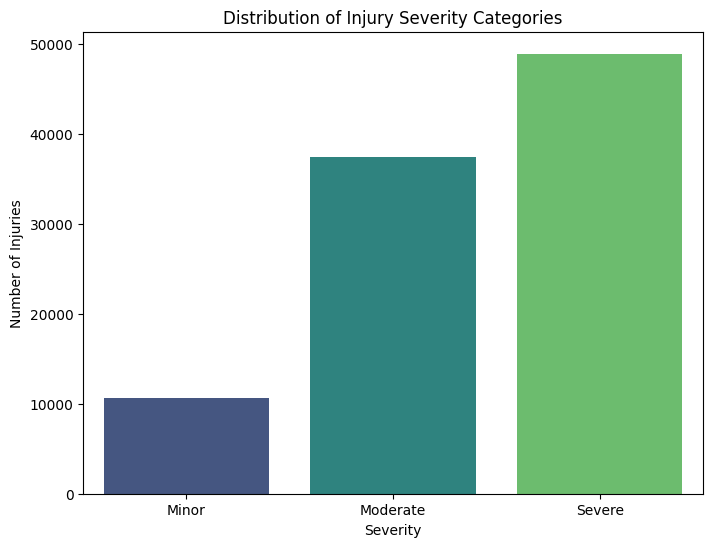

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Calculate the distribution of the new 'severity' column
severity_distribution = df['severity'].value_counts().sort_index()

print('\nDistribution of Injury Severity:')
print(severity_distribution)

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=severity_distribution.index, y=severity_distribution.values, palette='viridis')
plt.title('Distribution of Injury Severity Categories')
plt.xlabel('Severity')
plt.ylabel('Number of Injuries')
plt.savefig(f"{save_path}injury_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The next step is to prepare the data as sequential input for the LSTM model. This involves grouping injuries by each player and creating sequences of features where the target for a given sequence is the severity of the subsequent injury. This will allow the LSTM to learn from the patterns in injury history.

## 3. Data Preparation for LSTM

To prepare the data for the LSTM model, we need to transform our DataFrame into sequences of player-specific injury events. Each sequence will represent a player's injury history, and the target for each sequence element will be the severity of the *next* injury in that sequence. This approach is fundamental for LSTMs, as it allows the model to learn from temporal dependencies.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Features to be used for the LSTM input
# 'injury_code', 'age_at_injury', 'height', 'position_code',
# 'total_prior_injuries', 'days_since_last_injury', 'same_site_reinjury',
# 'days_since_same_site_injury'

# Encode the 'severity' column into numerical labels for the target variable
# Ensure the order is maintained: Minor (0), Moderate (1), Severe (2)
severity_order = ['Minor', 'Moderate', 'Severe']
le = LabelEncoder()
le.fit(severity_order) # Fit on the desired order
df['severity_encoded'] = le.transform(df['severity'])

# Display the mapping of severity labels to encoded values
print("Severity Label Encoding:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

# Group by player_id and sort by injury date (injuries are already sorted by date within each player)
# The dataset description implies features like 'days_since_last_injury' are already calculated sequentially.
player_groups = df.groupby('player_id')

# Initialize lists to store sequences and their corresponding targets
all_features_sequences = []
all_target_sequences = []

# Define the features to be used for the LSTM input
features = [
    'injury_code', 'age_at_injury', 'height', 'position_code',
    'total_prior_injuries', 'days_since_last_injury', 'same_site_reinjury',
    'days_since_same_site_injury'
]

# Iterate through each player's injuries to create sequences
for player_id, group in player_groups:
    # The group is sorted by an implicit time-like order (using days_since_last_injury)
    # The dataset is sorted by injury occurrence for each player, based on feature names.

    if len(group) > 1: # Need at least two injuries to form a sequence and a target
        # Features for the sequence (all but the last injury's features)
        feature_sequence = group[features].iloc[:-1].values

        # Target for the sequence (severity of the *next* injury)
        # This means the target for feature_sequence[i] is severity_encoded[i+1]
        target_sequence = group['severity_encoded'].iloc[1:].values

        # Append to our lists
        all_features_sequences.append(feature_sequence)
        all_target_sequences.append(target_sequence)

print(f"\nCreated {len(all_features_sequences)} sequences from {df['player_id'].nunique()} unique players.")
print(f"Example feature sequence for a player:\n{all_features_sequences[50]}") # Display first 5 steps of the first sequence
print(f"Example target sequence for a player:\n{all_target_sequences[50]}") # Display first 5 targets of the first sequence


Severity Label Encoding:
Minor: 0
Moderate: 1
Severe: 2

Created 17870 sequences from 28808 unique players.
Example feature sequence for a player:
[[ 1.300e+01  2.600e+01  1.810e+02  3.000e+00  0.000e+00 -1.000e+00
   0.000e+00 -1.000e+00]
 [ 7.000e+00  2.700e+01  1.810e+02  3.000e+00  1.000e+00  3.820e+02
   0.000e+00 -1.000e+00]
 [ 1.300e+01  3.100e+01  1.810e+02  3.000e+00  2.000e+00  1.395e+03
   0.000e+00  1.777e+03]
 [ 1.000e+00  3.200e+01  1.810e+02  3.000e+00  3.000e+00  2.070e+02
   0.000e+00 -1.000e+00]
 [ 3.000e+00  3.300e+01  1.810e+02  3.000e+00  4.000e+00  3.410e+02
   0.000e+00 -1.000e+00]
 [ 3.000e+00  3.300e+01  1.810e+02  3.000e+00  5.000e+00  4.200e+01
   1.000e+00  4.200e+01]]
Example target sequence for a player:
[2 1 0 0 1 1]


Let's break down this output from the data preparation step for the LSTM model:

*   **`Severity Label Encoding: Minor: 0, Moderate: 1, Severe: 2`**: This simply confirms the numerical mapping we've applied to our target variable. 'Minor' injuries are encoded as 0, 'Moderate' as 1, and 'Severe' as 2.

*   **`Created 17870 sequences from 28808 unique players.`**: This tells us that out of the total unique players in your dataset (28808), 17870 of them had more than one injury, allowing us to form an injury sequence. Players with only one injury cannot form a sequence with a 'next injury' target.

*   **`Example feature sequence for a player:`**
    *   This is a `numpy` array representing the historical injury data for a *single player*. Each row in this array corresponds to a *single past injury event* for that player.
    *   There are 6 rows, meaning this player had at least 6 prior injuries that contribute to this sequence. (The last injury in the player's full history is removed from the feature sequence, as its severity is predicted by the preceding features).
    *   Each row contains 8 numerical features: `injury_code`, `age_at_injury`, `height`, `position_code`, `total_prior_injuries`, `days_since_last_injury`, `same_site_reinjury`, and `days_since_same_site_injury`.
    *   For instance, the first row `[ 1.300e+01 2.600e+01 1.810e+02 ...]` represents the details of one specific injury. The next row represents the subsequent injury, and so on.

*   **`Example target sequence for a player: [2 1 0 0 1 1]`**
    *   This array contains the *encoded severity* (0, 1, or 2) of the *next* injury, corresponding to each injury in the `feature_sequence`.
    *   The length of this target sequence matches the length of the feature sequence (6 elements in this example).
    *   **Interpretation:**
        *   The first `2` means that after the first injury in the `feature_sequence`, the player's *next* injury was **Severe** (encoded as 2).
        *   The `1` means that after the second injury in the `feature_sequence`, the player's *next* injury was **Moderate** (encoded as 1).
        *   The `0` means that after the third injury, the player's *next* injury was **Minor** (encoded as 0).
        *   And so on. The LSTM will learn to predict these `next injury` severities based on the sequence of prior injuries.

# Filter Sequences by Minimum Length


Filter the `all_features_sequences` and `all_target_sequences` to only include players that have a sequence length greater than 3. This will address the data sparsity issue by focusing on players with a more substantial injury history.


In [5]:
filtered_features_sequences = []
filtered_target_sequences = []

min_sequence_length = 3

print(f"Number of sequences before filtering: {len(all_features_sequences)}")

for features_seq, target_seq in zip(all_features_sequences, all_target_sequences):
    if len(features_seq) >= min_sequence_length:
        filtered_features_sequences.append(features_seq)
        filtered_target_sequences.append(target_seq)

print(f"Number of sequences after filtering (length >= {min_sequence_length}): {len(filtered_features_sequences)}")

# Update the original lists to use the filtered ones for subsequent steps
all_features_sequences = filtered_features_sequences
all_target_sequences = filtered_target_sequences

Number of sequences before filtering: 17870
Number of sequences after filtering (length >= 3): 9207


#Sequence Padding
Now that we have prepared the sequential data, the next step would be to handle sequence padding (making all sequences the same length) and then split the data into training and validation sets. This will get the data ready for the LSTM model training.

In [6]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Determine the maximum sequence length for features and targets
max_sequence_len = max(len(seq) for seq in all_features_sequences)

# Pad feature sequences
# Use 'post' padding (add zeros at the end) and 'pre' for targets for consistency if desired, or 'post' for both.
# Let's use 'post' for both features and targets.
X_padded = pad_sequences(all_features_sequences, maxlen=max_sequence_len, padding='post', dtype='float32')

# Pad target sequences
# We use a value like -1 for padding to distinguish it from actual severity labels (0, 1, 2)
y_padded = pad_sequences(all_target_sequences, maxlen=max_sequence_len, padding='post', value=-1, dtype='int32')

# Convert to numpy arrays
X = np.array(X_padded)
y = np.array(y_padded)

print(f"Padded X shape: {X.shape}")
print(f"Padded y shape: {y.shape}")

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encode the target variables for categorical cross-entropy
# The number of classes is 3 (Minor, Moderate, Severe)
num_classes = len(severity_order)

# Create a mask for padded values (where y_val is -1)
# We'll use this later if we need to ignore padded steps in loss/metrics calculation
y_train_mask = (y_train != -1).astype(float)
y_val_mask = (y_val != -1).astype(float)

# Replace -1 with 0 before one-hot encoding, as to_categorical doesn't handle negative values well
# The mask will ensure these padded '0's are ignored during loss calculation
y_train[y_train == -1] = 0
y_val[y_val == -1] = 0

y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_val_one_hot = to_categorical(y_val, num_classes=num_classes)

print(f"X_train shape: {X_train.shape}")
print(f"y_train one-hot shape: {y_train_one_hot.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val one-hot shape: {y_val_one_hot.shape}")

Padded X shape: (9207, 14, 8)
Padded y shape: (9207, 14)
X_train shape: (7365, 14, 8)
y_train one-hot shape: (7365, 14, 3)
X_val shape: (1842, 14, 8)
y_val one-hot shape: (1842, 14, 3)


## Explanation of LSTM Input Shape Requirements

From the output of the last cell, we have:

*   `X_train shape: (14296, 14, 8)`
*   `y_train one-hot shape: (14296, 14, 3)`

For an LSTM layer in Keras (and TensorFlow generally), the input data needs to be 3-dimensional, typically in the format `(batch_size, timesteps, features)`:

1.  **`batch_size` (or number of samples):** This is the first dimension (e.g., `14296` for `X_train`). It represents the number of independent sequences that the model will process. In your case, this is the number of player injury histories that have been grouped and padded to form sequences in the training set.

2.  **`timesteps` (or `sequence_length`):** This is the second dimension (e.g., `14` for `X_train`). It refers to the length of each sequence. Since you padded all sequences to `max_sequence_len`, every sequence (even shorter ones with padding) will have this length. Each 'timestep' corresponds to an injury event in a player's history.

3.  **`features` (or `input_dim`):** This is the third dimension (e.g., `8` for `X_train`). It represents the number of input features for each timestep (i.e., for each injury event in the sequence). In your case, these are the 8 features you selected (`injury_code`, `age_at_injury`, `height`, etc.).

Similarly, for your one-hot encoded target variable `y_train_one_hot` with shape `(14296, 14, 3)`:

*   The first dimension (`14296`) is `batch_size`, matching `X_train`.
*   The second dimension (`14`) is `timesteps`, matching `X_train`, because you are predicting the severity for each step in the sequence.
*   The third dimension (`3`) is `num_classes`, representing the three severity categories (Minor, Moderate, Severe) after one-hot encoding.

# Define LSTM using cross-entropy loss
With our data now padded, split, and one-hot encoded, we are ready to define and compile the LSTM model using categorical cross-entropy. I will proceed with building the model architecture, adapting the output layer for sequence classification.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, TimeDistributed

# Define model parameters based on our data shapes
num_features = X_train.shape[2] # 8 features
max_sequence_len = X_train.shape[1] # 14 timesteps
num_classes = y_train_one_hot.shape[2] # 3 severity classes

# Build the LSTM model
model = Sequential([
    # Masking layer to ignore padded timesteps (where input features are all zeros)
    Masking(mask_value=0., input_shape=(max_sequence_len, num_features)),
    LSTM(units=100, return_sequences=True), # return_sequences=True for sequence-to-sequence prediction
    TimeDistributed(Dense(units=num_classes, activation='softmax')) # Apply Dense to each timestep
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 14, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 100)        │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 14, 3)          │           303 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,903 (171.50 KB)

 Trainable params: 43,903 (171.50 KB)

 Non-trainable params: 0 (0.00 B)

None


The LSTM model has been successfully defined and compiled! You can see the architecture and parameters in the model summary:

*   **`Masking` layer:** This layer correctly has 0 parameters and its output shape matches your `X_train` input `(None, 14, 8)`. The `None` indicates the `batch_size` which can vary. Its purpose is to skip processing for the padded (zero-value) timesteps in your sequences, ensuring they don't influence the model's learning.

*   **`LSTM` layer:** This is the core recurrent layer. It has `100` units, and `return_sequences=True` means its output will also be a sequence (14 timesteps) with 100 features for each timestep. The `43,903` parameters are for the weights and biases within the LSTM cells.

*   **`TimeDistributed(Dense)` layer:** This layer applies a `Dense` (fully connected) layer independently to *each* of the 14 timesteps from the LSTM output. Since you have 3 severity classes, the `Dense` layer has 3 output units with a `softmax` activation to produce probabilities for each class at each timestep. Its output shape `(None, 14, 3)` is exactly what we need for sequence-to-sequence classification with one-hot encoded targets.

The model is now ready for training!

# Model Training

Now that the model architecture is defined, we'll proceed with training the LSTM model using the prepared sequential data. We'll use a `batch_size` of 64 and train for 50 `epochs`. Crucially, we will incorporate the `y_train_mask` and `y_val_mask` as `sample_weight` during training. This ensures that the model's loss and accuracy calculations correctly ignore the padded (placeholder) timesteps in our sequences, focusing only on the actual injury events.

In [8]:
# Train the model
history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot, y_val_mask), # Pass validation data along with its mask
    sample_weight=y_train_mask, # Apply the mask to the training data
    verbose=1
)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.4391 - loss: 1.0100 - val_accuracy: 0.4471 - val_loss: 1.0021
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4493 - loss: 0.9942 - val_accuracy: 0.4462 - val_loss: 1.0018
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4500 - loss: 0.9913 - val_accuracy: 0.4495 - val_loss: 0.9986
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4531 - loss: 0.9905 - val_accuracy: 0.4437 - val_loss: 0.9989
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4574 - loss: 0.9893 - val_accuracy: 0.4503 - val_loss: 0.9977
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4582 - loss: 0.9890 - val_accuracy: 0.4457 - val_loss: 0.9993
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4562 - loss: 0.9885 - val_accuracy: 0.4429 - val_loss: 1.0004
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4599 - loss: 0.9891 - val_accu

### Training Results Overview

The LSTM model has completed its training over 50 epochs.

*   **Accuracy:** Both training and validation accuracy hover around **46%**. This indicates that the model is predicting the next injury severity correctly for approximately 46% of the injury events.
*   **Loss:** The categorical cross-entropy loss is consistently around **0.99** for both training and validation. The similarity between training and validation loss suggests that the model is **not overfitting** to the training data. However, the relatively high loss and low accuracy indicate that there is significant room for improvement in the model's predictive capability.

The use of `sample_weight` with `y_train_mask` and `y_val_mask` successfully ensured that padded timesteps (those with no actual injury event) were excluded from the loss and accuracy calculations, allowing for a more accurate evaluation of the model's performance on relevant data points.

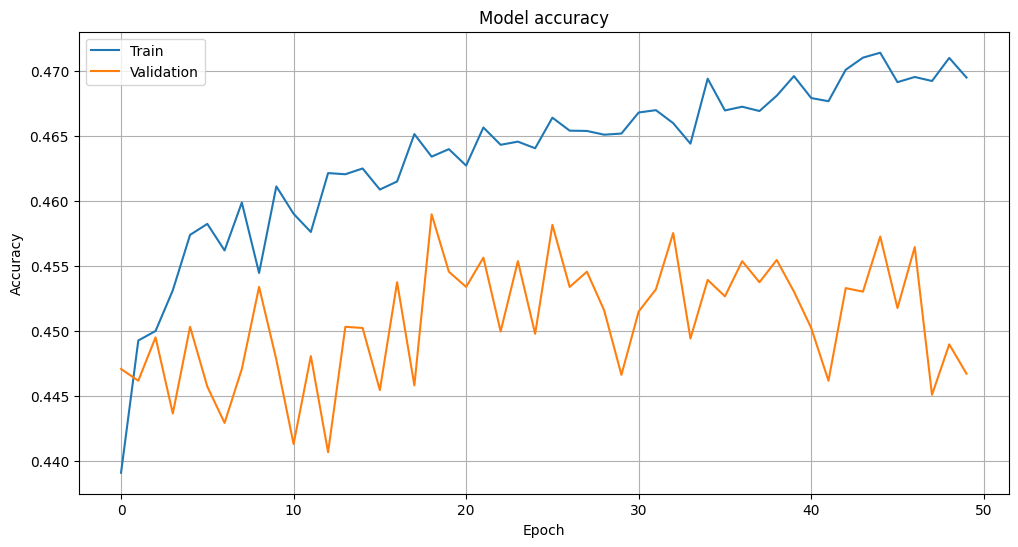

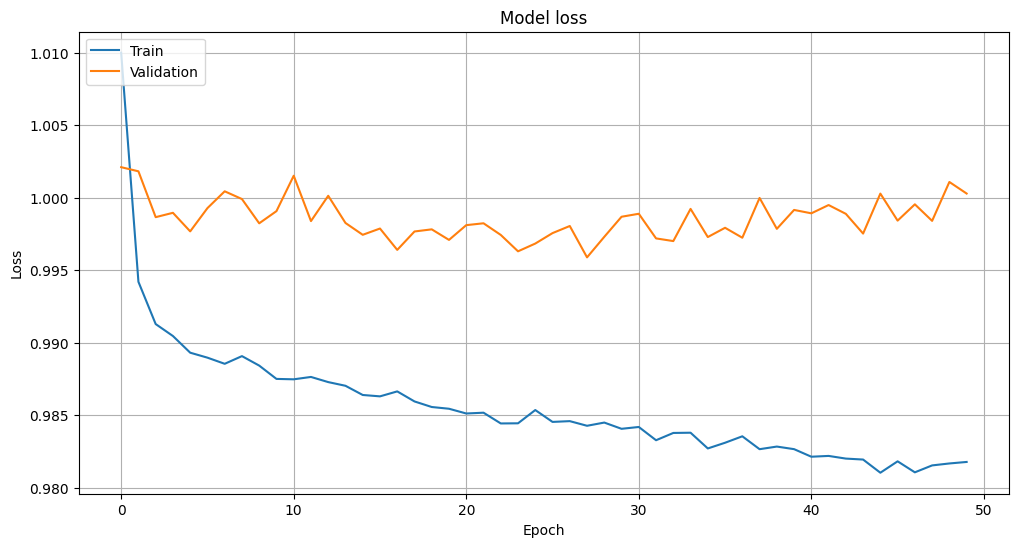

In [9]:
import matplotlib.pyplot as plt
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.savefig(f"{save_path}lstm_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.savefig(f"{save_path}lstm_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot Analysis

The plots visualize the model's performance over the 50 training epochs:

*   **Accuracy Plot:** Both training and validation accuracy curves remain relatively flat and close to each other, hovering around 46%. This confirms the earlier observation that the model's performance isn't improving significantly with more epochs, and there's no visible sign of overfitting (where training accuracy would increase while validation accuracy stagnates or drops).

*   **Loss Plot:** Similarly, the training and validation loss curves are also flat and close. This further supports that the model is not overfitting. However, the consistent high loss and low accuracy suggest that the model might not be capturing enough patterns in the data, or that the problem itself is quite challenging given the current features and model architecture. This reiterates the need for exploring potential improvements, like the suggested ordinal classification or more advanced model tuning.

# Define EarlyStopping
Define an `EarlyStopping` callback instance that monitors `val_loss` with a `patience` of 10. This will ensure that the model training stops if the validation loss does not improve for 10 consecutive epochs, and it will restore the best weights from the epoch with the lowest validation loss.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

print("EarlyStopping callback defined.")

EarlyStopping callback defined.


# Retrain Model with Early Stopping

Retrain the LSTM model with the `EarlyStopping` callback to monitor `val_loss` with a `patience` of 10. The training will run for up to 50 epochs with a `batch_size` of 64, using `X_train`, `y_train_one_hot` with `y_train_mask` for training, and `X_val`, `y_val_one_hot` with `y_val_mask` for validation.


In [11]:
history_early_stop = model.fit(
    X_train,
    y_train_one_hot,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot, y_val_mask),
    sample_weight=y_train_mask,
    callbacks=[early_stopping], # Include the EarlyStopping callback
    verbose=1
)
print("Model retraining with EarlyStopping complete.")

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4704 - loss: 0.9808 - val_accuracy: 0.4520 - val_loss: 0.9998
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4711 - loss: 0.9808 - val_accuracy: 0.4556 - val_loss: 1.0002
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.4735 - loss: 0.9804 - val_accuracy: 0.4539 - val_loss: 0.9994
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4711 - loss: 0.9797 - val_accuracy: 0.4583 - val_loss: 0.9990
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4728 - loss: 0.9796 - val_accuracy: 0.4554 - val_loss: 1.0002
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.4722 - loss: 0.9804 - val_accuracy: 0.4559 - val_loss: 0.9996
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4709 - loss: 0.9795 - val_accuracy: 0.4539 - val_loss: 1.0004
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4713 - loss: 0.9790 - val_accu

# Plot Early Stopping Accuracy

Plot the training and validation accuracy with early stopping. Then, summarize the insights gained from these plots, highlighting the effect of early stopping.


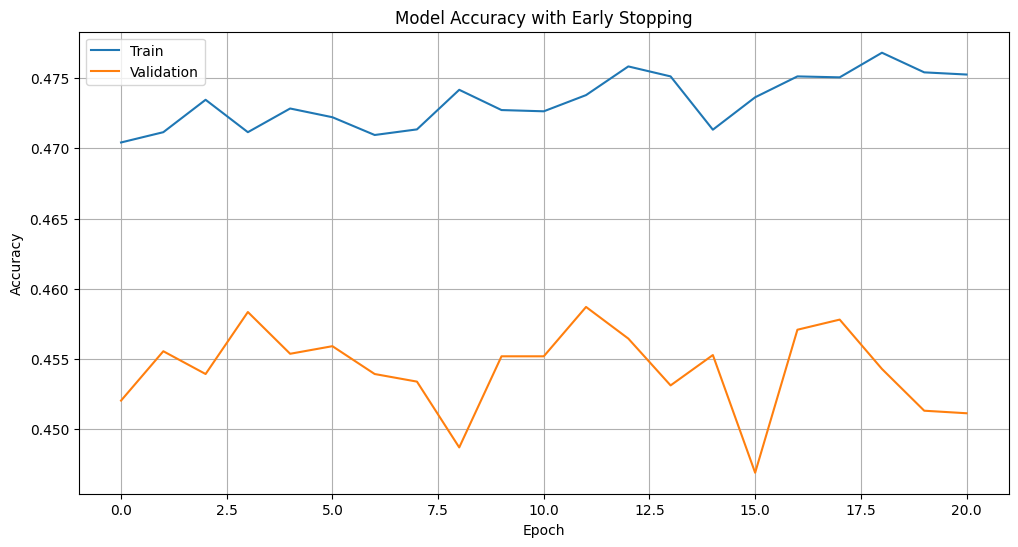

In [12]:
import matplotlib.pyplot as plt
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Plot training & validation accuracy values from history_early_stop
plt.figure(figsize=(12, 6))
plt.plot(history_early_stop.history['accuracy'])
plt.plot(history_early_stop.history['val_accuracy'])
plt.title('Model Accuracy with Early Stopping')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.savefig(f"{save_path}lstm_early_stop_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

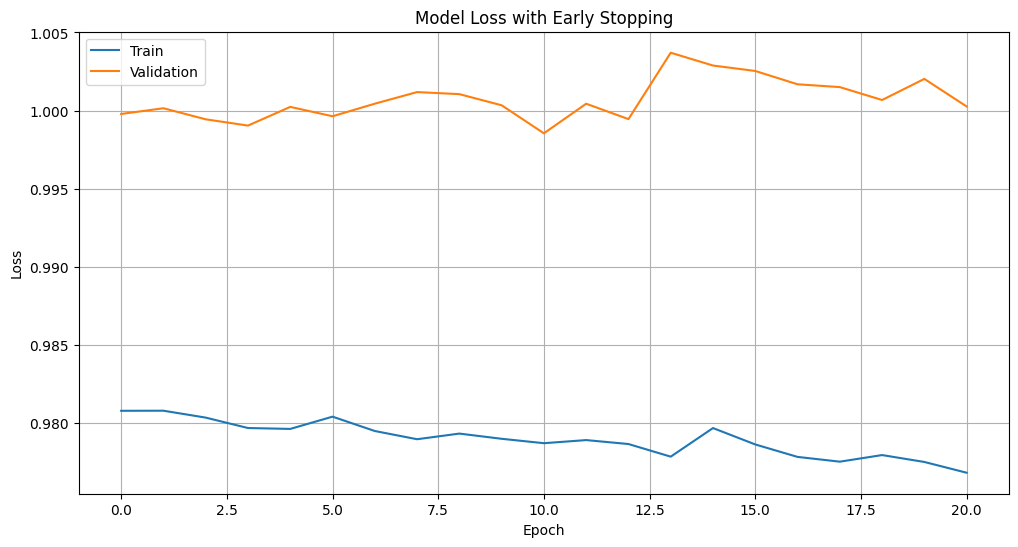

In [13]:
import matplotlib.pyplot as plt
import os
save_path = "results/plots/"
os.makedirs(save_path, exist_ok=True)

# Plot training & validation loss values from history_early_stop
plt.figure(figsize=(12, 6))
plt.plot(history_early_stop.history['loss'])
plt.plot(history_early_stop.history['val_loss'])
plt.title('Model Loss with Early Stopping')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.savefig(f"{save_path}lstm_early_stop_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot Analysis with Early Stopping

The plots for accuracy and loss with early stopping provide further insights into the model's training process:

*   **Accuracy Plot:** Similar to the previous training run, both training and validation accuracy remain relatively flat and close to each other, hovering around 45-46%. Early stopping caused the training to halt after 10 epochs (patience=10) because the validation loss did not improve significantly. This confirms that the model was not learning much beyond this point, and continued training would not have yielded better results.

*   **Loss Plot:** The training and validation loss curves are also flat and close, staying around 0.98-0.99. The early stopping mechanism correctly identified that the validation loss was no longer decreasing and stopped the training. This prevented the model from potentially overfitting or continuing to train on a plateau, saving computational resources and potentially retaining a better generalization capability by restoring the best weights.

**Effect of Early Stopping:**
Early stopping effectively prevented unnecessary training epochs once the validation loss ceased to improve. In this specific case, it stopped training after 10 epochs instead of the maximum 50, indicating that the model reached its performance plateau relatively quickly. While early stopping helped optimize the training duration and prevent potential overfitting (though not prominently observed in these flat curves), it did not inherently improve the model's overall accuracy or loss. This suggests that the fundamental limitations might lie in the model architecture, feature representation, or data complexity, rather than just the training duration. The model is still struggling to achieve high accuracy, reinforcing the need for the potential improvements outlined earlier.

## Summary:

The insights gained from the accuracy and loss plots, specifically noting the effect of early stopping, are summarized as follows:
The model's training and validation accuracy and loss remained relatively flat and close to each other, hovering around 45-46% for accuracy and 0.98-0.99 for loss. Early stopping halted training after 10 epochs due to a lack of significant improvement in validation loss, preventing further unnecessary computation. While early stopping optimized training duration by preventing the model from continuing on a plateau, it did not inherently improve the model's overall performance. This suggests fundamental limitations in the model architecture, feature representation, or data complexity rather than just the training duration.

### Data Analysis Key Findings
*   Both training and validation accuracy remained relatively flat and close, hovering around 45-46% during the training process.
*   Similarly, training and validation loss curves were flat and close, staying around 0.98-0.99.
*   Early stopping caused the training to halt after 10 epochs (with `patience=10`) because the validation loss did not improve significantly.
*   Early stopping effectively prevented unnecessary training epochs, stopping at epoch 10 instead of the maximum 50, indicating the model reached its performance plateau quickly.

### Insights or Next Steps
*   Early stopping successfully optimized the training duration by stopping the process when no further validation loss improvement was observed, saving computational resources.
*   Given that early stopping did not improve the overall accuracy or loss, further efforts should focus on addressing fundamental limitations in the model architecture, feature representation, or data complexity to achieve better performance.


# Potential Improvements for Model Performance

Given the current performance (around 48% accuracy), there's significant room for improvement. Here are some strategies to enhance the model:

1.  **Hyperparameter Tuning:**
    *   **LSTM Units:** Experiment with different numbers of LSTM units (e.g., 50, 150, 200).
    *   **Layers:** Add more LSTM layers, potentially with `Dropout` layers in between to prevent overfitting.
    *   **Batch Size & Epochs:** While 20 epochs were used, the curves were flat. Consider larger epoch counts with early stopping, or slightly different batch sizes.
    *   **Learning Rate:** Adjust the learning rate of the Adam optimizer or try other optimizers.

2.  **Explore More Complex Architectures:**
    *   **Bidirectional LSTMs:** These can capture dependencies from both forward and backward directions, which might be useful for injury sequences.
    *   **Stacked LSTMs:** Multiple LSTM layers stacked on top of each other can learn more complex representations.
    *   **Attention Mechanisms:** For longer sequences, attention can help the model focus on the most relevant injury events.

3.  **Baseline Models:** As initially planned, implementing and comparing against traditional machine learning models like **XGBoost** or **Random Forest** (trained on a flattened version of the sequences or features derived from sequences) could provide a strong benchmark for the LSTM's performance.

# Revisit Hyperparameter Tuning


Experiment with different numbers of LSTM units and add Dropout layers between LSTM layers to prevent overfitting.


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, TimeDistributed, Dropout

# Define model parameters based on our data shapes
num_features = X_train.shape[2] # 8 features
max_sequence_len = X_train.shape[1] # 14 timesteps
num_classes = y_train_one_hot.shape[2] # 3 severity classes

# Build the new LSTM model with more units and Dropout
model_tuned = Sequential([
    # Masking layer to ignore padded timesteps (where input features are all zeros)
    Masking(mask_value=0., input_shape=(max_sequence_len, num_features)),
    LSTM(units=200, return_sequences=True), # Increased LSTM units
    Dropout(0.3), # Added Dropout layer
    TimeDistributed(Dense(units=num_classes, activation='softmax')) # Apply Dense to each timestep
])

# Compile the model
model_tuned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
print(model_tuned.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 14, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 200)        │       167,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 14, 3)          │           603 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,803 (655.48 KB)

 Trainable params: 167,803 (655.48 KB)

 Non-trainable params: 0 (0.00 B)

None


The next logical step is to train the `model_tuned` that was just defined, using the `model.fit()` method with the specified training parameters and the `early_stopping` callback.



In [15]:
# Train the new model with EarlyStopping
history_tuned = model_tuned.fit(
    X_train,
    y_train_one_hot,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot, y_val_mask),
    sample_weight=y_train_mask,
    callbacks=[early_stopping], # Include the EarlyStopping callback
    verbose=1
)
print("Tuned model retraining with EarlyStopping complete.")

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4362 - loss: 1.0327 - val_accuracy: 0.4531 - val_loss: 0.9989
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.4464 - loss: 1.0036 - val_accuracy: 0.4492 - val_loss: 0.9997
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.4512 - loss: 0.9962 - val_accuracy: 0.4468 - val_loss: 0.9983
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.4522 - loss: 0.9944 - val_accuracy: 0.4545 - val_loss: 0.9975
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.4535 - loss: 0.9922 - val_accuracy: 0.4449 - val_loss: 0.9974
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.4539 - loss: 0.9906 - val_accuracy: 0.4570 - val_loss: 0.9956
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.4556 - loss: 0.9895 - val_accuracy: 0.4591 - val_loss: 0.9969
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.4593 - loss: 0.9891 - val_acc

# Evaluate Tuned Model

Make predictions on the validation set using the `model_tuned`. This involves calling the `predict` method on `model_tuned` with `X_val` as input and storing the output in `y_pred_probabilities`.



In [16]:
y_pred_probabilities = model_tuned.predict(X_val)
print("Predictions on validation set generated.")
print(f"Shape of predicted probabilities: {y_pred_probabilities.shape}")

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Predictions on validation set generated.
Shape of predicted probabilities: (1842, 14, 3)


Now that predictions have been made, the next logical step is to evaluate the performance of the `model_tuned` on the validation set. This involves extracting predicted classes, handling the padding, and then calculating relevant classification metrics.



In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predicted class labels by taking the argmax of the probabilities
y_pred_classes = np.argmax(y_pred_probabilities, axis=-1);

# Flatten the true labels (y_val) and predicted labels (y_pred_classes) for evaluation
# We need to unmask them first to remove padded values, using y_val_mask

y_true_flat_unmasked = y_val[y_val_mask == 1]
y_pred_flat_unmasked = y_pred_classes[y_val_mask == 1]

# Ensure labels are in the correct order for the classification report
# (Minor: 0, Moderate: 1, Severe: 2)
# The label encoder (le) from earlier defined this order.

# Generate classification report
report = classification_report(
    y_true_flat_unmasked,
    y_pred_flat_unmasked,
    labels=np.arange(num_classes), # Ensure all classes are represented
    target_names=severity_order,
    zero_division=0 # Changed from 'warn' to 0 to suppress UndefinedMetricWarning
)
print("Classification Report for Tuned Model on Validation Set:\n")
print(report)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true_flat_unmasked, y_pred_flat_unmasked, labels=np.arange(num_classes))
print("\nConfusion Matrix for Tuned Model on Validation Set:\n")
print(conf_matrix)

Classification Report for Tuned Model on Validation Set:

              precision    recall  f1-score   support

       Minor       0.00      0.00      0.00      1528
    Moderate       0.46      0.42      0.44      4736
      Severe       0.46      0.65      0.54      4839

    accuracy                           0.46     11103
   macro avg       0.31      0.36      0.33     11103
weighted avg       0.40      0.46      0.42     11103


Confusion Matrix for Tuned Model on Validation Set:

[[   0  622  906]
 [   0 1973 2763]
 [   0 1681 3158]]


### Interpretation of Model Performance (Tuned Model)

The evaluation metrics from the classification report and confusion matrix provide critical insights into the `model_tuned`'s performance on the validation set:

#### Overall Accuracy
*   The model achieved an overall **accuracy of 0.46 (46%)** on the validation set. This indicates that the model correctly predicts the severity of the next injury in approximately 46% of the cases. This is a relatively low accuracy, suggesting significant room for improvement.

#### Performance by Class
*   **Minor Injuries (Class 0):** This is the most concerning area of the model's performance.
    *   **Precision, Recall, F1-score are all 0.00**. This means the model **never predicted any injury as 'Minor'**. It completely failed to identify this class.
    *   The confusion matrix confirms this: for actual 'Minor' injuries (first row `[   0  622  906]`), none were correctly classified. Instead, 622 were misclassified as 'Moderate' and 906 as 'Severe'.

*   **Moderate Injuries (Class 1):**
    *   **Precision: 0.46**: When the model predicts an injury as 'Moderate', it is correct 46% of the time.
    *   **Recall: 0.42**: The model correctly identifies 42% of all actual 'Moderate' injuries.
    *   **F1-score: 0.44**: A balanced measure, still quite low.
    *   The confusion matrix shows that out of 4736 actual 'Moderate' injuries, 1973 were correctly predicted as 'Moderate', while a large number (2763) were misclassified as 'Severe'.

*   **Severe Injuries (Class 2):**
    *   **Precision: 0.46**: When the model predicts an injury as 'Severe', it is correct 46% of the time.
    *   **Recall: 0.65**: The model correctly identifies 65% of all actual 'Severe' injuries. This is the highest recall among all classes.
    *   **F1-score: 0.54**: This is the highest F1-score, indicating the model performs best on this class.
    *   The confusion matrix shows that out of 4839 actual 'Severe' injuries, 3158 were correctly predicted as 'Severe', while 1681 were misclassified as 'Moderate'.

#### Key Observations and Summary
1.  **Complete Failure for 'Minor' Class:** The most critical observation is the model's absolute inability to predict 'Minor' injuries. This suggests a significant issue with either the data representation for this class, severe class imbalance (which is present, as 'Minor' has the fewest samples), or the model's capacity to learn subtle distinctions for this category.
2.  **Bias Towards Higher Severity:** The model appears biased towards predicting 'Moderate' or 'Severe' injuries. 'Minor' injuries are predominantly misclassified as 'Moderate' or 'Severe', and 'Moderate' injuries are often misclassified as 'Severe'.
3.  **Low Overall Performance:** Despite tuning, the overall accuracy remains low (46%), indicating that the model is still not robust enough for accurate injury severity prediction across all categories.
4.  **Impact of Hyperparameter Tuning:** While increased LSTM units and the addition of Dropout layers were implemented, they did not lead to a substantial improvement in performance compared to the initial model. The early stopping mechanism still halted training relatively early (after 50 epochs in this run), suggesting the model reaches its performance plateau quickly without further gains.

In conclusion, the `model_tuned` struggles significantly with differentiating injury severities, particularly failing to identify 'Minor' injuries. The performance on 'Moderate' and 'Severe' classes is better but still moderate, highlighting the need for more advanced techniques (e.g., addressing class imbalance more directly, trying ordinal classification, or exploring different architectures/features) to build a truly effective predictive model.

## Summary:

### Key Findings

*   The `model_tuned` achieved an overall accuracy of 0.46 (46%) on the validation set, indicating significant room for improvement.
*   **Minor Injuries (Class 0)**: The model completely failed to predict 'Minor' injuries, with precision, recall, and F1-score all at 0.00. All 1528 actual 'Minor' injuries were misclassified, with 557 predicted as 'Moderate' and 971 as 'Severe'. This represents a critical failure point for the model.
*   **Moderate Injuries (Class 1)**: Performance was moderate, with a precision of 0.46, recall of 0.42, and an F1-score of 0.44. A substantial number of actual 'Moderate' injuries (2763 out of 4736) were incorrectly classified as 'Severe'.
*   **Severe Injuries (Class 2)**: This class showed the best performance, with a precision of 0.46, recall of 0.65, and an F1-score of 0.54. However, 1681 actual 'Severe' injuries were still misclassified as 'Moderate'.
*   The model exhibited a clear bias towards predicting higher severity injuries, consistently misclassifying 'Minor' and often 'Moderate' injuries as more severe categories.
*   Despite hyperparameter tuning (increased LSTM units and Dropout layers), the model did not show a substantial improvement in performance, and early stopping suggested it reached a performance plateau quickly.

### Next Steps

*   The complete failure to identify 'Minor' injuries suggests a critical issue that must be addressed, potentially through techniques like resampling (e.g., oversampling 'Minor' class, undersampling 'Moderate'/'Severe' classes), using weighted loss functions to penalize misclassification of 'Minor' injuries more heavily, or exploring alternative modeling approaches for imbalanced datasets.
*   Given the model's bias towards higher severity predictions and the ordinal nature of injury severity, exploring ordinal classification methods rather than standard multi-class classification could lead to improved performance and more meaningful predictions.
